In [118]:
import pandas as pd
import numpy as np

In [119]:
#reading the data as csv file and coverting it into the tabular data frame format
student_data=pd.read_csv("Student_Performance.csv")
student_dataframe=pd.DataFrame(student_data)
student_dataframe.head(10)

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f
5,6,19,male,public,no formal,3.8,69.6,yes,>60 min,yes,coaching,51.5,78.3,63.9,63.5,d
6,7,14,female,private,post graduate,1.8,81.6,yes,30-60 min,no,textbook,41.9,29.4,39.2,39.1,f
7,8,18,female,private,post graduate,5.6,59.4,yes,>60 min,yes,group study,56.7,60.1,53.4,69.6,d
8,9,15,other,private,high school,3.2,89.6,yes,15-30 min,yes,mixed,54.1,59.5,38.3,55.2,d
9,10,14,female,public,diploma,6.8,62.4,yes,>60 min,no,mixed,71.9,70.4,81.3,69.6,d


In [120]:
#initial stage of the data table of student performance
student_dataframe.shape

(25000, 16)

In [121]:
#we will get overall structure of the data frame
student_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

In [122]:
#description of the data frame
student_dataframe.describe()

,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,7493.04380,16.482760,4.253224,75.084084,63.785944,63.745320,63.681948,64.006172
std,4323.56215,1.703895,2.167541,14.373171,20.875262,20.970529,20.792693,18.932025
min,1.00000,14.000000,0.500000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,3743.75000,15.000000,2.400000,62.800000,48.300000,48.200000,48.300000,49.000000
50%,7461.50000,16.000000,4.300000,75.100000,64.100000,64.100000,64.200000,64.200000
75%,11252.00000,18.000000,6.100000,87.500000,80.000000,80.000000,80.000000,79.000000
max,15000.00000,19.000000,8.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [123]:
#knowing the null data present in the data frame
null_data=student_dataframe.isnull().sum().sum()
print("null data present:",null_data)

null data present: 0


In [124]:
#searching for the duplicate values
data_duplicated=student_dataframe.duplicated().sum()
print("the duplicated data present:",data_duplicated)

the duplicated data present: 10000


In [125]:
#removing the duplicate values
student_dataframe=student_dataframe.drop_duplicates(keep="first")
data_duplicated=student_dataframe.duplicated().sum()
print("the duplicated data present:",data_duplicated)

the duplicated data present: 0


In [126]:
#removed the duplicate data and knowing its shape 
student_dataframe.shape

(15000, 16)

In [127]:
# Droping ID column,internet_access,extra_activities these we unwanted
student_dataframe=student_dataframe.drop(columns=["student_id","internet_access","extra_activities"])
student_dataframe

,age,gender,school_type,parent_education,study_hours,attendance_percentage,travel_time,study_method,math_score,science_score,english_score,overall_score,final_grade
0,14,male,public,post graduate,3.1,84.3,<15 min,notes,42.7,55.4,57.0,53.1,e
1,18,female,public,graduate,3.7,87.8,>60 min,textbook,57.6,68.8,64.8,61.3,d
2,17,female,private,post graduate,7.9,65.5,<15 min,notes,84.8,95.0,79.2,89.6,b
3,16,other,public,high school,1.1,58.1,15-30 min,notes,44.4,27.5,54.7,41.6,e
4,16,female,public,high school,1.3,61.0,30-60 min,group study,8.9,32.7,30.0,25.4,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,17,male,private,graduate,1.8,53.2,15-30 min,group study,37.1,37.1,26.8,38.4,f
14996,17,other,private,diploma,6.7,63.5,<15 min,mixed,84.4,67.2,96.2,78.8,c
14997,17,male,private,phd,5.2,58.2,30-60 min,group study,69.0,57.2,74.1,64.3,d
14998,16,other,private,graduate,1.0,68.7,30-60 min,textbook,24.2,41.4,30.5,33.6,f


In [128]:
#the unique will return unique values present in the data set that will occur at least once
student_dataframe['final_grade'].unique()

array(['e', 'd', 'b', 'f', 'c', 'a'], dtype=object)

In [129]:
#as i want togenerate the heat map then i want all the numerical values so i turned thegrades in to number format
grade_mapping = {"a":1, "b":2, "c":3, "d":4, "e":5, "f":6}

# Normalize values (strip spaces + lowercase) and map
student_dataframe['final_grade'] = student_dataframe['final_grade'].astype(str).str.strip().str.lower().map(grade_mapping)

In [130]:
#final_grades are changed into numbers
student_dataframe['final_grade'].unique()

array([5, 4, 2, 6, 3, 1])

In [131]:
student_dataframe.head(10)

,age,gender,school_type,parent_education,study_hours,attendance_percentage,travel_time,study_method,math_score,science_score,english_score,overall_score,final_grade
0,14,male,public,post graduate,3.1,84.3,<15 min,notes,42.7,55.4,57.0,53.1,5
1,18,female,public,graduate,3.7,87.8,>60 min,textbook,57.6,68.8,64.8,61.3,4
2,17,female,private,post graduate,7.9,65.5,<15 min,notes,84.8,95.0,79.2,89.6,2
3,16,other,public,high school,1.1,58.1,15-30 min,notes,44.4,27.5,54.7,41.6,5
4,16,female,public,high school,1.3,61.0,30-60 min,group study,8.9,32.7,30.0,25.4,6
5,19,male,public,no formal,3.8,69.6,>60 min,coaching,51.5,78.3,63.9,63.5,4
6,14,female,private,post graduate,1.8,81.6,30-60 min,textbook,41.9,29.4,39.2,39.1,6
7,18,female,private,post graduate,5.6,59.4,>60 min,group study,56.7,60.1,53.4,69.6,4
8,15,other,private,high school,3.2,89.6,15-30 min,mixed,54.1,59.5,38.3,55.2,4
9,14,female,public,diploma,6.8,62.4,>60 min,mixed,71.9,70.4,81.3,69.6,4


                            age  study_hours  attendance_percentage  \
age                    1.000000     0.004240               0.004521   
study_hours            0.004240     1.000000              -0.009486   
attendance_percentage  0.004521    -0.009486               1.000000   
math_score             0.000575     0.802971               0.252210   
science_score          0.008525     0.804551               0.248960   
english_score          0.002694     0.804208               0.253859   
overall_score          0.004981     0.905885               0.288473   
final_grade           -0.000616    -0.879310              -0.282533   

                       math_score  science_score  english_score  \
age                      0.000575       0.008525       0.002694   
study_hours              0.802971       0.804551       0.804208   
attendance_percentage    0.252210       0.248960       0.253859   
math_score               1.000000       0.785904       0.788176   
science_score            

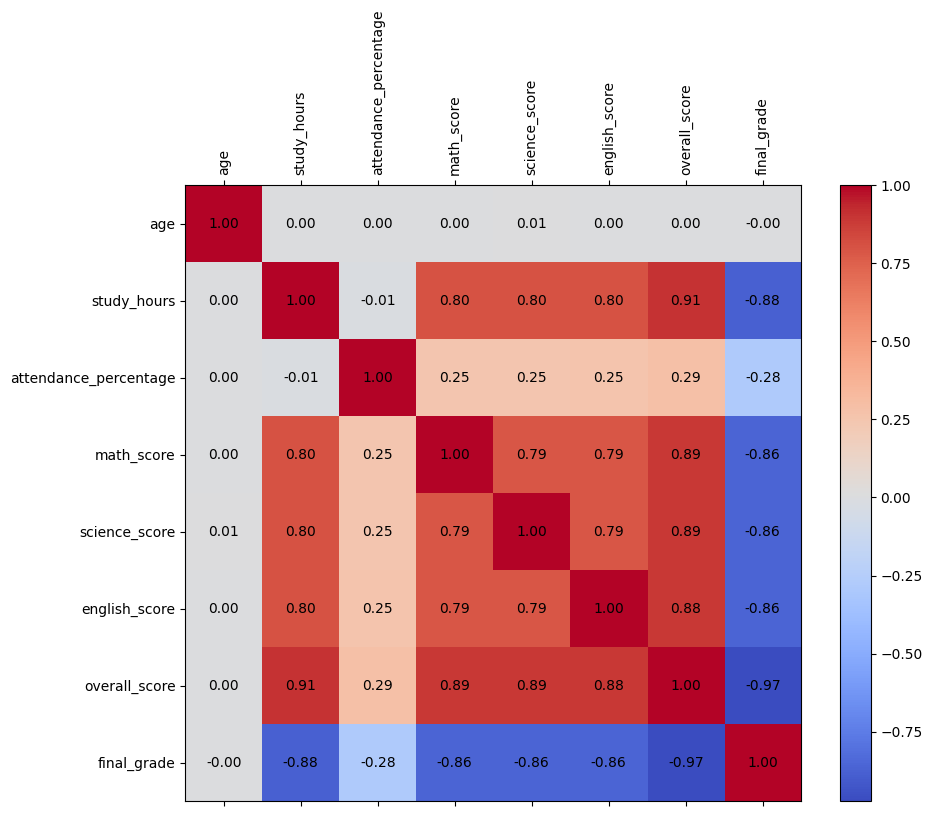

In [132]:
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = student_dataframe[[
    "age","study_hours","attendance_percentage",
    "math_score","science_score","english_score",
    "overall_score","final_grade"
]]

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Print relation values
print(corr_matrix)

# Plot heatmap with values
fig, ax = plt.subplots(figsize=(10,8))
cax = ax.matshow(corr_matrix, cmap="coolwarm")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.colorbar(cax)

# Add correlation values on the heatmap
for (i, j), val in np.ndenumerate(corr_matrix.values):
    ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="black")

plt.show()


In [133]:
#from the above heat map i have observed that i have 'study_hours' & 'overall_score' has the strong co realation
print(student_dataframe[['study_hours','overall_score']].corr())

               study_hours  overall_score
study_hours       1.000000       0.905885
overall_score     0.905885       1.000000


Intercept: 30.473038892101876
Coefficient: [7.88203609]
R² Score: 0.8233937086905013
RMSE: 65.2137071027447


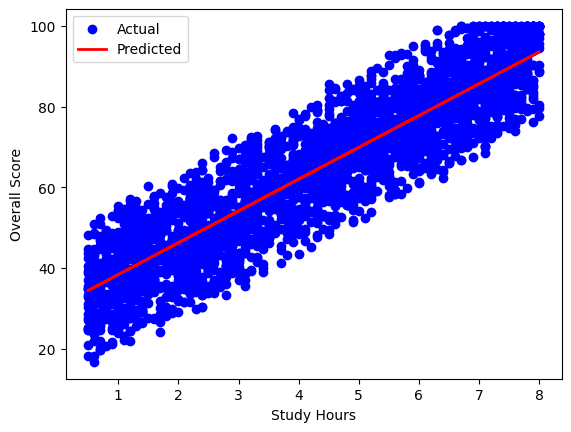

In [134]:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Features (X) and Target (y)
X = student_dataframe[['study_hours']]
y = student_dataframe['overall_score']

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

# Plot regression line
plt.scatter(X_test, y_test, color="blue", label="Actual")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Predicted")
plt.xlabel("Study Hours")
plt.ylabel("Overall Score")
plt.legend()
plt.show()


In [139]:
# Example: predict overall_score for a student who studies 8 hours
new_value = [[2]]   # must be 2D array
prediction = model.predict(new_value)

print(f"Predicted Overall Score for {new_value} study hours: {prediction[0]:.2f}")


Predicted Overall Score for [[2]] study hours: 46.24


C:\Users\grand\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
